In [20]:
# import the usual suspects
import numpy as np
import os
import matplotlib.pyplot as plt
import pandas as pd
from src.cf_generator_dice import DiceCFGenerator
from src.data_processor import DataProcessor
from src.model_trainer import ModelTrainer
from src.utils import load_config,check_file_exists,print_balancing, plot_confusion_ascii, write_time
from src.fancy_plots import build_cmap
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score, roc_auc_score,balanced_accuracy_score

In [3]:
# let's find the different files we need
config = load_config('config.yaml')
cf_results = config['paths']['counterfactuals']
dt_name = "german_credit"

cf_results

'counterfactuals/'

In [4]:
data_processor = DataProcessor(config=config)
splits = data_processor.load_splits(dt_name)


Loaded feature names from data/processed\german_credit\feature_names.csv
Loaded X_train from data/processed\german_credit\X_train.npz
Loaded y_train from data/processed\german_credit\y_train.npz
Loaded X_test from data/processed\german_credit\X_test.npz
Loaded y_test from data/processed\german_credit\y_test.npz
Loaded X_calibration from data/processed\german_credit\X_calibration.npz
Loaded y_calibration from data/processed\german_credit\y_calibration.npz


In [5]:

model_trainer = ModelTrainer(config)
models = model_trainer.train_model(X_train=splits['X_train'], 
                                    y_train=splits['y_train'], 
                                    X_test=splits['X_test'], 
                                    y_test=splits['y_test'],
                                    dataset_name=dt_name)
print(models.keys())

Processing random_forest for german_credit
Loaded random_forest model from models/german_credit\random_forest.pkl
Loaded existing random_forest model
Processing mlp for german_credit
Loaded mlp model from models/german_credit\mlp.pkl
Loaded existing mlp model
Processing xgboost for german_credit
Loaded xgboost model from models/german_credit\xgboost.pkl
Loaded existing xgboost model
Processing lgbm for german_credit
Loaded lgbm model from models/german_credit\lgbm.pkl
Loaded existing lgbm model
dict_keys(['random_forest', 'mlp', 'xgboost', 'lgbm'])


In [6]:
for k in models.keys():
    roc = roc_auc_score(splits['y_test'], models[k].predict_proba(splits['X_test'])[:,1]).round(2)
    print(f"Model {k} ROC AUC: {roc}")
    acc = accuracy_score(splits['y_test'], models[k].predict(splits['X_test'])).round(2)
    print(f"Model {k} Accuracy: {acc}")
    f1_ = f1_score(splits['y_test'], models[k].predict(splits['X_test']), average='weighted').round(2)
    print(f"Model {k} F1 Score: {f1_}")
    balanced_accuracy = balanced_accuracy_score(splits['y_test'], models[k].predict(splits['X_test'])).round(2)
    print(f"Model {k} Balanced Accuracy: {balanced_accuracy}")
    #print(classification_report(splits['y_test'], models[k].predict(splits['X_test'])))
    plot_confusion_ascii(splits['y_test'], models[k].predict(splits['X_test']))
    # print(confusion_matrix(splits['y_test'], models[k].predict(splits['X_test'])))
    print()
    

Model random_forest ROC AUC: 0.79
Model random_forest Accuracy: 0.77
Model random_forest F1 Score: 0.74
Model random_forest Balanced Accuracy: 0.66
O.
.O

Model mlp ROC AUC: 0.74
Model mlp Accuracy: 0.73
Model mlp F1 Score: 0.71
Model mlp Balanced Accuracy: 0.63
Oo
.o

Model xgboost ROC AUC: 0.77
Model xgboost Accuracy: 0.74
Model xgboost F1 Score: 0.73
Model xgboost Balanced Accuracy: 0.65
O.
.O

Model lgbm ROC AUC: 0.77
Model lgbm Accuracy: 0.75
Model lgbm F1 Score: 0.73
Model lgbm Balanced Accuracy: 0.66
O.
.O



In [7]:
# import the fancy for bar chart tdqm
from  tqdm.notebook import tqdm,tnrange, tqdm_notebook
import time




In [8]:
np.random.randint(0,7), np.random.rand()*7

(4, 2.591945095858813)

  0%|          | 0/4 [00:00<?, ?it/s]

looking into the folder  counterfactuals/random_forest\german_credit


  0%|          | 0/200 [00:00<?, ?it/s]

looking into the folder  counterfactuals/mlp\german_credit


  0%|          | 0/200 [00:00<?, ?it/s]

looking into the folder  counterfactuals/xgboost\german_credit


  0%|          | 0/200 [00:00<?, ?it/s]

looking into the folder  counterfactuals/lgbm\german_credit


  0%|          | 0/200 [00:00<?, ?it/s]

C:\Users\user\AppData\Local\Temp\ipykernel_29880\2779784449.py:112: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


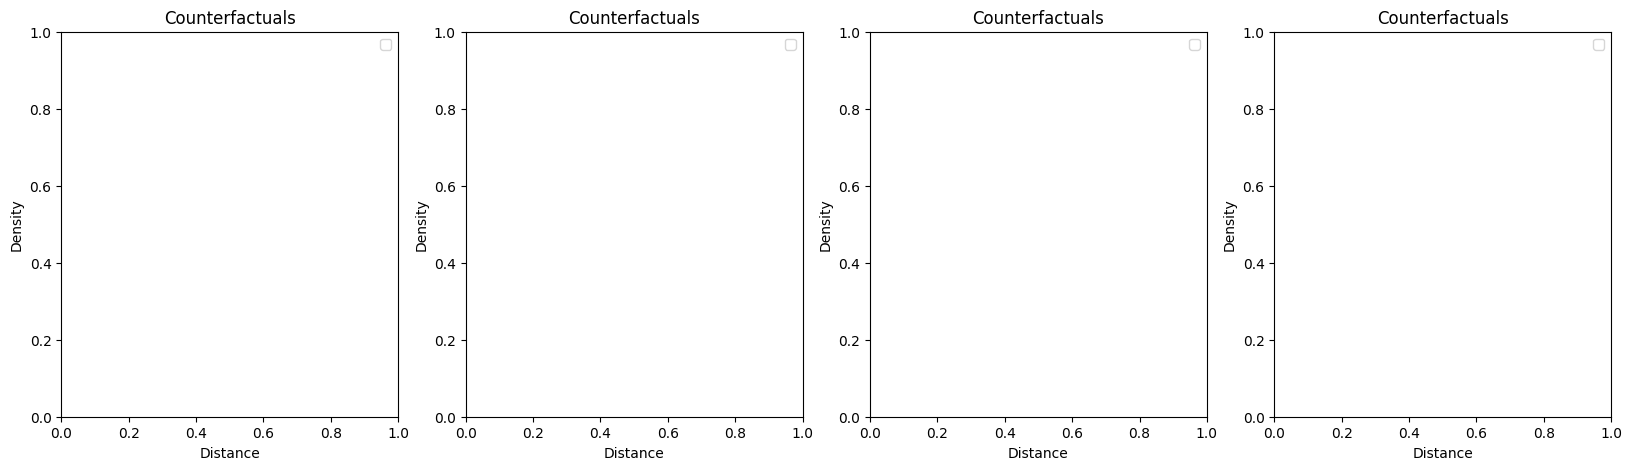

In [81]:
counterfactuals = {k: [] for k in models.keys()}

# create 4 subplots
fig, axs = plt.subplots(1, 4, figsize=(20, 5))
axs = axs.flatten()
all_ranking_list_mean = {k:None for k in models.keys()}
all_ranking_list_std = {k:None for k in models.keys()}
all_ranking_list_min = {k:None for k in models.keys()}
all_ranking_list_max = {k:None for k in models.keys()}
all_probabs = {k:None for k in models.keys()}
def get_mean_distance(x,y,policy="l2"):
    if policy == "l2":
        return np.linalg.norm(x-y,axis=1)
    elif policy == "mae":
        return np.abs(x-y).mean(axis=1)
    

    
start = time.time()
for k in tqdm(models.keys()):
    # load the counterfactuals
    result_folder_path = os.path.join(cf_results,
                        k,
                        dt_name)
    print("looking into the folder ",result_folder_path)
    '''results = os.listdir(result_folder_path)
    print(len(results))
    # take the most recent using os.path.getmtime
    results = sorted(results,key=lambda x: os.path.getmtime(os.path.join(result_folder_path,x)),reverse=True)

    print("for model",k,"using file",results[-1])
    r = results[-1]
    
    print("checking",r)
    starting2 = time.time()
    # load the counterfactuals most recent using nupy
    cfs = np.load(os.path.join(result_folder_path, r),allow_pickle=True)#results[0]), allow_pickle=True)
    # cfs is a dictionary with keys "cfs" as the only key (it's an npz file)
    # the value of "cfs" is a np array of dictionaries
    # the keys of the dictionaries are 
    # - instace_idx (the index of the instance in the calibration set)
    # - original_instance (the original class of the instance)
    # - true_class (the true class of the instance)
    '''
    mean_dists = []
    std_dists = []
    min_dists = []
    max_dists = []
    probabs = []

    cfs = {"cfs":np.arange(200)}
    
    for i in tnrange(cfs["cfs"].shape[0]):
        # since we are now in a local server just create fake data to test the plots
        mean_dists.append(np.random.rand()*7)
        std_dists.append(np.random.randint(0,2))
        min_dists.append(mean_dists[-1]-std_dists[-1])
        max_dists.append(mean_dists[-1]+std_dists[-1])
        probabs.append(mean_dists[-1]/7+np.random.rand(2)*0.01)
        probabs[-1] = probabs[-1]/probabs[-1].sum()


        continue
        
        # print(cfs["cfs"][0].keys())
        # print(cfs["cfs"][0]["metadata"])
        # print(cfs["cfs"][0]["original_instance"])
        # print(cfs["cfs"][0]["counterfactuals"].target)
        ## just because I don't believe it, let's see the output for the original instance
        ## and check if the model is predicting the class (even to check what true_class is)
        ## then we can check the counterfactuals and see if the model is predicting the opposite class
        ## and if it aligns with the "target" attribute of the counterfactuals
        original_instance = cfs["cfs"][i]["original_instance"]
        true_cf = cfs["cfs"][i]["counterfactuals"].target.values
        pred = models[k].predict(original_instance)
        pred_prob = models[k].predict_proba(original_instance)[0]
        


        good_cfs = cfs["cfs"][i]["counterfactuals"].values[:,:-1]
        good_cfs = good_cfs[true_cf != pred]
        true_cf = true_cf[true_cf != pred]
        if len(true_cf) == 0:
            distancies = np.array([np.inf])
            print("NOT FOUND COUNTERFACTUALS FOR SAMPLE",i)
        else:
            assert (true_cf-true_cf.mean() == 0).all(), "The counterfactuals are not aligned with the target"+str(true_cf)
            #distancies = np.linalg.norm(good_cfs - cfs["cfs"][i]["original_instance"].values,axis=1)
            distancies = get_mean_distance(good_cfs, cfs["cfs"][i]["original_instance"].values)
        mean_dists.append(distancies.mean(axis=0))
        std_dists.append(distancies.std(axis=0))
        min_dists.append(distancies.min(axis=0))
        max_dists.append(distancies.max(axis=0))
        probabs.append(pred_prob)

        # print(distancies)
        if i / 4 < 1:
            sns.kdeplot(distancies,cumulative=False,label=str(i)+" "+str(len(distancies))+ " counterfactuals "+k,ax=axs[i])

    
    all_ranking_list_mean[k] = mean_dists
    all_ranking_list_std[k] = std_dists
    all_ranking_list_min[k] = min_dists
    all_ranking_list_max[k] = max_dists
    all_probabs[k] = probabs
    #print("Time for model",k,"is",write_time(time.time()-starting2))
#print("Time from start",write_time(time.time()-start))
# plot legend for each ax
for ax in axs:
    # put legend under the plot
    #ax.set_xlim([-3,13])
    ax.legend()
    ax.set_xlabel("Distance")
    ax.set_ylabel("Density")
    ax.set_title("Counterfactuals")
plt.show()
        
            




In [82]:
# now we can see the ranking of the counterfactuals
rankings = [all_ranking_list_mean,
                     all_ranking_list_std,
                     all_ranking_list_min,
                     all_ranking_list_max]

all_ranking_list_max.keys()

dict_keys(['random_forest', 'mlp', 'xgboost', 'lgbm'])

In [83]:
rank_10_vals = {}
for r in rankings:
    for k in r.keys():
        r[k] = np.array(r[k])
        rank_10_vals[k] = None

In [84]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [85]:
np.array(all_ranking_list_max["mlp"]).shape
# use kmeans and get the 10


names = ["mean","std","min","max"]
for k in tqdm(list(models.keys())):
    for i,ranks in (enumerate(rankings)):
        if names[i] == "std":
            continue
        # remove the infinities
        ranks_nona = np.array(ranks[k][ranks[k]<np.inf])
        kmeans = KMeans(n_clusters=10, random_state=0,n_init=5).fit(np.array(ranks_nona).reshape(-1,1))
        ran = kmeans.cluster_centers_.reshape(-1)
        ran.sort()
        df = pd.DataFrame(ran,columns=[names[i]+"_ranks"])
        print("model:",k,names[i])
        #print(df)
        rank_10_vals[k] = ran
        #break
    #break
    print()

  0%|          | 0/4 [00:00<?, ?it/s]

model: random_forest mean
model: random_forest min
model: random_forest max

model: mlp mean
model: mlp min
model: mlp max

model: xgboost mean
model: xgboost min
model: xgboost max

model: lgbm mean
model: lgbm min
model: lgbm max



Text(0.5, 0.98, 'Ranking of distances of Counterfactuals')

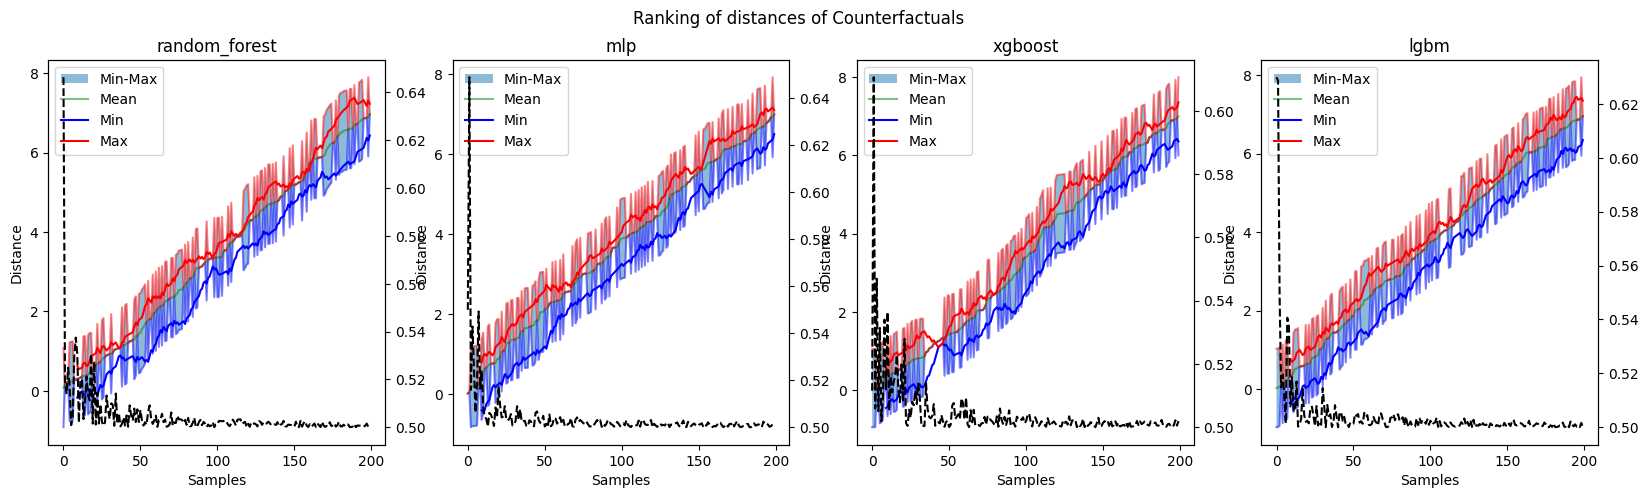

In [86]:
# now the plots!
# create 4 subplots
fig, axs = plt.subplots(1, 4, figsize=(20, 5))
axs = axs.flatten()
# each model goes in a different subplot
# we plot the sorted values of the minimum and the maximum distances,
# then we shade the area between them. On top of that we plot the mean
# at each data point we plot a vertical line with the std value of the distances, centeed at the mean

min_color = "blue"
max_color = "red"
mean_color = "green"

for i,k in enumerate(models.keys()):
    # plot the min and max values
    argsorted = all_ranking_list_mean[k].argsort()
    #print(argsorted)
    rank_m =    all_ranking_list_min[k][argsorted]
    rank_M =    all_ranking_list_max[k][argsorted]
    rank_mean = all_ranking_list_mean[k][argsorted]
    rank_std =  all_ranking_list_std[k][argsorted]
    axs[i].fill_between(np.arange(len(rank_m)),rank_m,rank_M,alpha=0.5,label="Min-Max")
    axs[i].plot(rank_m,alpha=0.5,color=min_color)
    axs[i].plot(rank_mean,label="Mean",alpha=0.5,color=mean_color)
    axs[i].plot(rank_M,alpha=0.5,color=max_color)
    #axs[i].errorbar(np.arange(len(rank_m)),rank_mean,yerr=rank_std,label="Std")
    # plot the "smoothed" values
    axs[i].plot(np.arange(len(rank_m)),pd.Series(rank_m).rolling(10).mean(),label="Min",color=min_color)
    axs[i].plot(np.arange(len(rank_M)),pd.Series(rank_M).rolling(10).mean(),label="Max",color=max_color)
    
    axs[i].set_title(k)
    axs[i].legend()
    axs[i].set_xlabel("Samples")
    axs[i].set_ylabel("Distance")

    # get the other axis and plot the probabilities
    ax2 = axs[i].twinx()
    ax2.plot(np.arange(len(rank_m)),np.array(all_probabs[k]).max(axis=1)[argsorted],label="Probability",color="black",linestyle="--")
    

plt.suptitle("Ranking of distances of Counterfactuals")

KeyError: 'predict_proba'

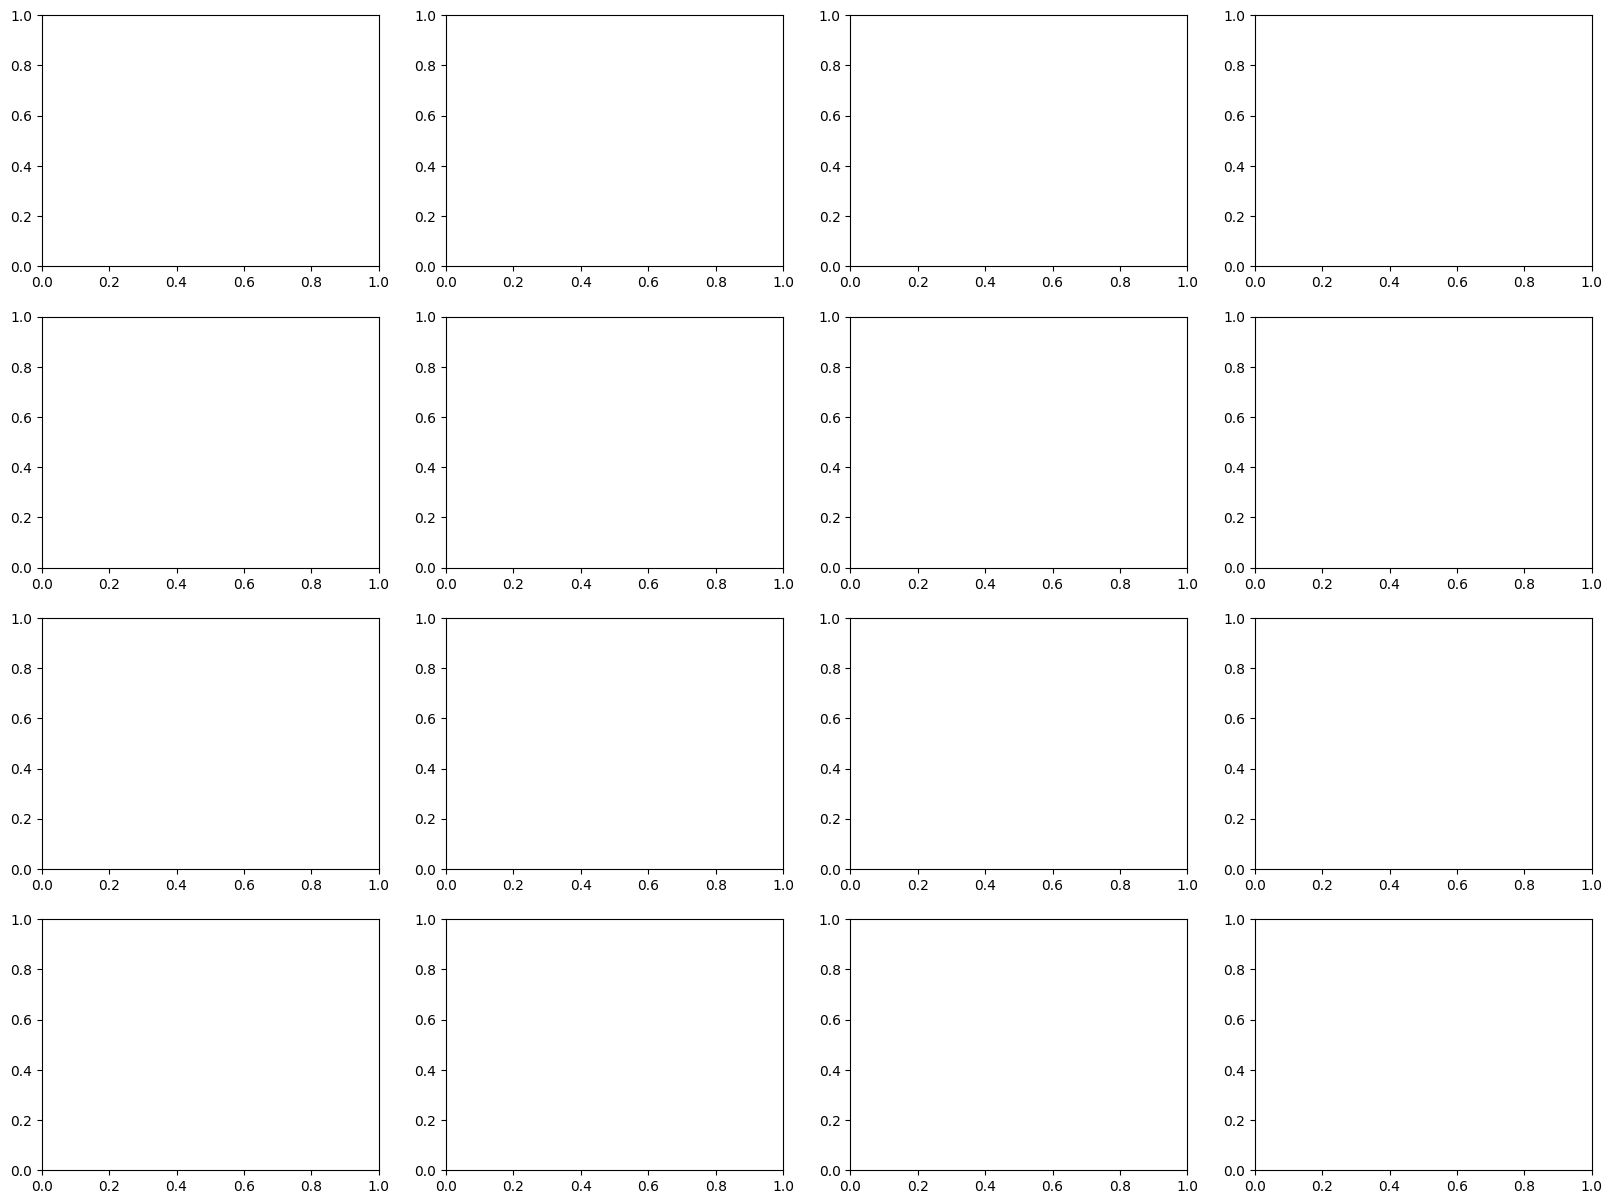

In [87]:
# now the plots!
# create 4 subplots

def create_plot_distances(dictionary,
                          sortby="mean",
                          axe=None,
                          title=None,
                          legend=False,colors = {"min":"blue","max":"red","mean":"black"},
                          ylim = None):
    if axe == None:
        axe = plt.gca()

    min_color = colors["min"]
    max_color = colors["max"]
    mean_color = colors["mean"]

    argsorted = dictionary[sortby].argsort()
    rank_m = dictionary["min"][argsorted]
    rank_M = dictionary["max"][argsorted]
    rank_mean = dictionary["mean"][argsorted]
    rank_prob = dictionary["predict_proba"][argsorted]
    axe.fill_between(np.arange(len(rank_m)),rank_m,rank_M,alpha=0.5,label="Min-Max")
    axe.plot(rank_m,alpha=0.5,color=min_color)
    axe.plot(rank_mean,label="Mean",alpha=0.5,color=mean_color)
    axe.plot(rank_M,alpha=0.5,color=max_color)
    #axe.errorbar(np.arange(len(rank_m)),rank_mean,yerr=rank_std,label="Std")
    # plot the "smoothed" values
    # axe.plot(np.arange(len(rank_m)),pd.Series(rank_m).rolling(5).mean(),label="Min",color=min_color)
    # axe.plot(np.arange(len(rank_mean)),pd.Series(rank_mean).rolling(5).mean(),label="Mean",color=mean_color)
    # axe.plot(np.arange(len(rank_M)),pd.Series(rank_M).rolling(5).mean(),label="Max",color=max_color)
    axe.set_title(sortby)
    if legend:
        axe.legend(fontsize=15)
    axe.set_xlabel("Ranks of samples, sorted by "+sortby,fontsize=15)
    axe.set_ylabel("Distance",fontsize=15)
    if title != None:
        axe.set_title(title,fontsize=18)
    axe.grid()    
    if ylim != None:
        ylims = axe.get_ylim()

        axe.set_ylim(ylims[0],ylim)
    if "predict_proba" in dictionary.keys():
        ax2 = axe.twinx()
        ax2.plot(np.arange(len(rank_m)),rank_prob,label="Probability",color="black",linestyle="--")
        ax2.set_ylim(0,1)
    axe.xaxis.set_tick_params(labelsize=15)
    axe.yaxis.set_tick_params(labelsize=15)
    return axe


fig, axs = plt.subplots(4, 4, figsize=(20, 15))
axs = axs.flatten()
# each model goes in a different subplot
# we plot the sorted values of the minimum and the maximum distances,
# then we shade the area between them. On top of that we plot the mean
# at each data point we plot a vertical line with the std value of the distances, centeed at the mean
c=0
for name in ["mean","min","max"]+["Predict Proba"]:
    for k in models.keys():
        create_plot_distances(dictionary={
                                "mean":all_ranking_list_mean[k],
                                "std":all_ranking_list_std[k],
                                "min":all_ranking_list_min[k],
                                "max":all_ranking_list_max[k],
                                "Predict Proba":np.array(all_probabs[k]).max(axis=1)},
                        sortby=name,
                        axe=axs[c],
                        title="model is "+k,
                        legend=(True if c %4== 0 else False),
                        ylim = 8)
        c+=1
plt.tight_layout()
plt.show()

In [76]:
# save the data on the disk under the debug folder 
# all the ranking and the counterfactuals's distances
import pickle
with open("debug/ranking.pkl","wb") as f:
    pickle.dump([all_ranking_list_mean,
                 all_ranking_list_std,
                 all_ranking_list_min,
                 all_ranking_list_max,
                 all_probabs],f)
                 
    
with open("debug/rank_10_vals.pkl","wb") as f:
    pickle.dump(rank_10_vals,f)


In [88]:
all_ranking_list_min.keys(),models.keys()

(dict_keys(['random_forest', 'mlp', 'xgboost', 'lgbm']),
 dict_keys(['random_forest', 'mlp', 'xgboost', 'lgbm']))

In [89]:
# check the correlation between the distances and the predict probailities of the model
# we can use the predict_proba of the model to get the probability of the class
correlations = {}
for k in models.keys():
    
    correlations[k] = {}
    print(f"Correlation between {k}'s output prob and the distances:")
    correlations[k]["min"] = np.corrcoef(all_ranking_list_min[k],  np.array(all_probabs[k]).max(axis=1))[0,1]
    correlations[k]["max"] = np.corrcoef(all_ranking_list_max[k],  np.array(all_probabs[k]).max(axis=1))[0,1]
    correlations[k]["mean"] = np.corrcoef(all_ranking_list_mean[k],np.array(all_probabs[k]).max(axis=1))[0,1]
    print("Min",np.round(correlations[k]["min"],3))
    print("Max",np.round(correlations[k]["max"],3))
    print("Mean",np.round(correlations[k]["mean"],3))
    print()

Correlation between random_forest's output prob and the distances:
Min -0.376
Max -0.362
Mean -0.379

Correlation between mlp's output prob and the distances:
Min -0.336
Max -0.368
Mean -0.363

Correlation between xgboost's output prob and the distances:
Min -0.413
Max -0.38
Mean -0.407

Correlation between lgbm's output prob and the distances:
Min -0.374
Max -0.319
Mean -0.357



In [123]:
correlations = pd.DataFrame(correlations).values

Text(95.72222222222221, 0.5, 'Distances')

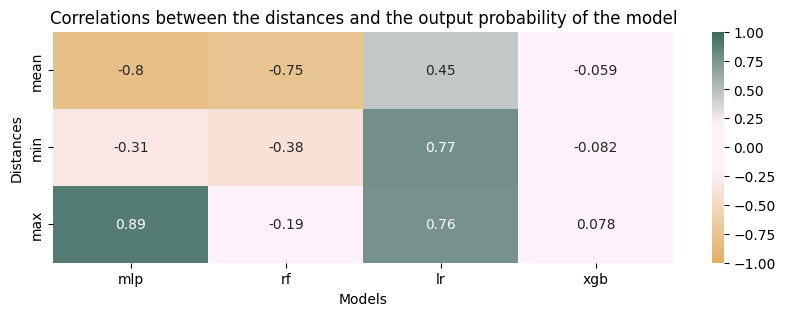

In [125]:
from src.fancy_plots import build_cmap, gold_map
from seaborn import cm
# def plot_correlations()
#correlations = np.random.rand(3,4)*2-1
#correlations.shape
# plot the correlations as colored ig squares with the value inside using sns
fig, ax = plt.subplots(1,1,figsize=(10,3))
gold_map_r  = build_cmap(0.2,'#deb062', '#fff1f9','#3c6b5e')

sns.heatmap(correlations,annot=True,ax=ax,vmin=-1,vmax=1,cmap=gold_map_r)#build_cmap(0.7,c1="blue",c3="red"))
ax.set_yticklabels(["mean","min","max"])
ax.set_xticklabels(["mlp","rf","lr","xgb"])
ax.set_title("Correlations between the distances and the output probability of the model")
plt.xlabel("Models")
plt.ylabel("Distances")

